# Data Analysis Pipeline
## Reorganized and Structured Code

This notebook performs:
1. Data loading and concatenation (df_math and df)
2. Statistical testing to find p-values
3. Mixed effects analysis with diagonal values
4. PCA analysis
5. Linear regression using math_test variables

## 1. Import Required Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as n
from itertools import combinations

# Statistical testing
from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from statsmodels.formula.api import mixedlm

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn import tree
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.linear_model import Ridge

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns




## 2. Data Loading and Preprocessing

In [529]:
# Load data files
df = pd.read_csv("overall_UTH(in).csv")
df_performance = pd.read_csv("Performance - UTH(Performance - UTH).csv")
df_math = pd.read_csv("Performance - UTH (2)(Sheet2).csv")

# Rename columns for consistency
df_math = df_math.rename(columns={'TOI': 'MathLevel'})
df = df.rename(columns={'TOI': 'MathLevel'})

print("Data loaded successfully!")
print(f"df shape: {df.shape}")
print(f"df_math shape: {df_math.shape}")
print(f"df_performance shape: {df_performance.shape}")

Data loaded successfully!
df shape: (350, 29)
df_math shape: (226, 6)
df_performance shape: (350, 16)


In [530]:

# Ensure both dataframes have 'Participant' and 'MathLevel' columns for proper merging
if 'Participant' in df_math.columns and 'Participant' in df.columns:
    # Merge on Participant and MathLevel
    df_combined = pd.merge(
        df_math, 
        df, 
        on=['Participant', 'MathLevel'], 
        how='outer',
        suffixes=('_math', '_df')
    )
else:
    # If no common identifier, concatenate vertically
    df_combined = pd.concat([df_math, df], axis=0, ignore_index=True)

print(f"Combined dataframe shape: {df_combined.shape}")
print("\nFirst few rows of combined data:")
df_combined = df_combined.dropna()
df_combined.head()

Combined dataframe shape: (351, 33)

First few rows of combined data:


,Participant,MathLevel,Count,Correct_Number,Correct_Percentage,Sign_Error,Strategy,StageNumber,#Digits,#CarriesPlace,...,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration,RelaAlpha,RelaBeta,RelaTheta,RelaDelta
0,MP10,1.0,19.0,19.0,100.0,0.0,2.0,1.0,2&1,0.0,...,3.0,1.0,2.0,2.0,3.0,1.0,-77.339831,20.744387,31.638375,25.957069
1,MP10,2.0,6.0,6.0,100.0,0.0,2.0,2.0,2&1,1.0,...,11.0,1.0,4.0,11.0,12.0,1.0,0.597666,-0.011833,0.043219,0.370948
2,MP10,5.0,3.0,3.0,100.0,0.0,2.0,3.0,3&2,1.0,...,11.0,1.0,4.0,12.0,13.0,1.0,0.346542,0.022614,0.105923,0.524921
3,MP10,7.0,4.0,4.0,100.0,0.0,2.0,3.0,2&2,1.0,...,10.0,1.0,3.0,10.0,9.0,1.0,0.391407,-0.004164,0.069117,0.543639
4,MP10,8.0,3.0,3.0,100.0,0.0,2.0,3.0,3&2,1.0,...,8.0,1.0,3.0,10.0,10.0,1.0,0.587006,-0.059261,-0.036016,0.508271


In [531]:
math_features = ['Count', 'Correct_Number', 'Correct_Percentage', 'Sign_Error']
available_math_features = [f for f in math_features if f in df_combined.columns]

print(f"Available math features: {available_math_features}")

# Extract features from df (eye-tracking + math-related)
feature_columns = [
    'Average_duration_of_whole_fixations',
    'Number_of_whole_fixations',
    'Average_whole_fixation_pupil_diameter',
    'Number_of_saccades',
    'Average_peak_velocity_of_saccades',
    'Average_amplitude_of_saccades',
    'Mental Demand',
    'Physical Demand',
    'Temporal Demand',
    'Performance',
    'Effort',
    'Frustration',
    'RelaAlpha',
    'RelaBeta',
    'RelaTheta',
    'RelaDelta'
] + available_math_features

feature_df = df_combined[feature_columns].select_dtypes(include=[np.number])

print(f"\nFeature dataframe shape: {feature_df.shape}")
feature_df.head()


Available math features: ['Count', 'Correct_Number', 'Correct_Percentage', 'Sign_Error']

Feature dataframe shape: (165, 20)


,Average_duration_of_whole_fixations,Number_of_whole_fixations,Average_whole_fixation_pupil_diameter,Number_of_saccades,Average_peak_velocity_of_saccades,Average_amplitude_of_saccades,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration,RelaAlpha,RelaBeta,RelaTheta,RelaDelta,Count,Correct_Number,Correct_Percentage,Sign_Error
0,744.0,5.0,4.13085,8.0,106.70,2.27,3.0,1.0,2.0,2.0,3.0,1.0,-77.339831,20.744387,31.638375,25.957069,19.0,19.0,100.0,0.0
1,1103.0,12.0,4.14223,6.0,111.40,1.75,11.0,1.0,4.0,11.0,12.0,1.0,0.597666,-0.011833,0.043219,0.370948,6.0,6.0,100.0,0.0
2,480.0,39.0,4.05711,38.0,133.90,4.26,11.0,1.0,4.0,12.0,13.0,1.0,0.346542,0.022614,0.105923,0.524921,3.0,3.0,100.0,0.0
3,465.0,25.0,3.99680,21.0,132.74,3.49,10.0,1.0,3.0,10.0,9.0,1.0,0.391407,-0.004164,0.069117,0.543639,4.0,4.0,100.0,0.0
4,515.0,29.0,4.01188,36.0,133.52,4.42,8.0,1.0,3.0,10.0,10.0,1.0,0.587006,-0.059261,-0.036016,0.508271,3.0,3.0,100.0,0.0


## 3. Statistical Analysis Functions

In [532]:
def analyze_features_across_mathlevels(df, features, alpha=0.05):
    results_list = []
    
    # Overall tests for each feature
    for feature in features:
        # Group data by MathLevel
        groups = [group[feature].values for name, group in df.groupby('MathLevel')]
        
        # Perform Kruskal-Wallis test (non-parametric ANOVA)
        h_stat, p_value = stats.kruskal(*groups)
        
        # Calculate overall effect size (eta squared)
        overall_mean = df[feature].mean()
        ss_between = sum(len(g) * (g.mean() - overall_mean)**2 for g in groups)
        ss_total = sum((df[feature] - overall_mean)**2)
        eta_squared = ss_between / ss_total if ss_total > 0 else 0
        
        results_list.append({
            'Feature': feature,
            'H_statistic': h_stat,
            'p_value': p_value,
            'Significant': 'Yes' if p_value < alpha else 'No',
            'Eta_squared': eta_squared
        })
    
    # Create results dataframe
    results_table = pd.DataFrame(results_list)
    
    # Calculate mean values for each MathLevel
    mean_values = df.groupby('MathLevel')[features].mean().round(2)
    
    # Count observations per MathLevel
    sample_sizes = df['MathLevel'].value_counts().sort_index()
    
    # Post-hoc pairwise comparisons for significant features
    pairwise_comparisons = {}
    significant_features = results_table[results_table['Significant'] == 'Yes']['Feature']
    
    for feature in significant_features:
        math_levels = sorted(df['MathLevel'].unique())
        pairwise_results = []
        
        for i in range(len(math_levels)):
            for j in range(i+1, len(math_levels)):
                level1 = math_levels[i]
                level2 = math_levels[j]
                
                group1 = df[df['MathLevel'] == level1][feature]
                group2 = df[df['MathLevel'] == level2][feature]
                
                u_stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')
                
                pairwise_results.append({
                    'Comparison': f'{level1} vs {level2}',
                    'U_statistic': u_stat,
                    'p_value': p_val,
                    'Significant': 'Yes' if p_val < alpha else 'No'
                })
        
        pairwise_comparisons[feature] = pd.DataFrame(pairwise_results)
    
    return {
        'results_table': results_table,
        'mean_values': mean_values,
        'sample_sizes': sample_sizes,
        'pairwise_comparisons': pairwise_comparisons
    }


def print_analysis_results(results):
    print("\n=== Statistical Test Results Across MathLevels ===")
    print(results['results_table'].to_string(index=False))
    
    print("\n=== Mean Values by MathLevel ===")
    print(results['mean_values'])
    
    print("\n=== Sample Size per MathLevel ===")
    print(results['sample_sizes'])
    
    if results['pairwise_comparisons']:
        print("\n=== Pairwise Comparisons (for significant features) ===")
        for feature, pairwise_df in results['pairwise_comparisons'].items():
            print(f"\n{feature}:")
            print(pairwise_df.to_string(index=False))
    else:
        print("\n=== No significant features found ===")


In [533]:
def analyze_composite_index_pairwise(df, features, alpha=0.05, figsize=(12, 10)):
    result_df = df.copy()
    math_levels = sorted(result_df['MathLevel'].unique())
    n_levels = len(math_levels)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(result_df[features])

    # PCA decomposition 
    pca = PCA(n_components= 3)
    X_pca = pca.fit_transform(X_scaled)

    explained_ratios = pca.explained_variance_ratio_[:3]
    total_variance = explained_ratios.sum()

    # Weighted composite index 
    weights = explained_ratios / explained_ratios.sum()  # normalize weights
    composite_index = (X_pca[:, :3] * weights).sum(axis=1)
    result_df['Composite_Index'] = composite_index

    # Compute per-level means 
    level_means = result_df.groupby('MathLevel')['Composite_Index'].mean()

    # Initialize matrices
    p_value_matrix = np.full((n_levels, n_levels), np.nan)
    mean_diff_matrix = np.full((n_levels, n_levels), np.nan)
    effect_size_matrix = np.full((n_levels, n_levels), np.nan)

    p_values_list = []
    comparisons = []

    # Pairwise Mann-Whitney U tests 
    for i in range(n_levels):
        for j in range(n_levels):
            level_i = math_levels[i]
            level_j = math_levels[j]

            if i == j:
                continue

            data_i = result_df[result_df['MathLevel'] == level_i]['Composite_Index']
            data_j = result_df[result_df['MathLevel'] == level_j]['Composite_Index']

            # Mann-Whitney test
            u_stat, p_val = mannwhitneyu(data_i, data_j, alternative='two-sided')

            # Mean difference and Cohen's d
            mean_diff = level_means[level_i] - level_means[level_j]
            pooled_std = np.sqrt((data_i.std()**2 + data_j.std()**2) / 2)
            cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0

            if i < j:
                p_value_matrix[i, j] = p_val
                p_values_list.append(p_val)
                comparisons.append((i, j))
            else:
                mean_diff_matrix[i, j] = mean_diff
                effect_size_matrix[i, j] = cohens_d

    # FDR-BH correction 
    if p_values_list:
        reject, p_corrected, _, _ = multipletests(p_values_list, method='fdr_bh')
        for idx, (i, j) in enumerate(comparisons):
            p_value_matrix[i, j] = p_corrected[idx]

    #  Prepare heatmap annotation 
    annotation_matrix = np.empty((n_levels, n_levels), dtype=object)
    display_matrix = np.zeros((n_levels, n_levels))

    for i in range(n_levels):
        for j in range(n_levels):
            if i == j:
                annotation_matrix[i, j] = f"{level_means[math_levels[i]]:.3f}"
                display_matrix[i, j] = 0
            elif i < j:
                p_val = p_value_matrix[i, j]
                display_matrix[i, j] = p_val
                if p_val < 0.001:
                    annotation_matrix[i, j] = f"{p_val:.4f}***"
                elif p_val < 0.01:
                    annotation_matrix[i, j] = f"{p_val:.3f}**"
                elif p_val < alpha:
                    annotation_matrix[i, j] = f"{p_val:.3f}*"
                else:
                    annotation_matrix[i, j] = f"{p_val:.3f}"
            else:
                display_matrix[i, j] = mean_diff_matrix[i, j]
                annotation_matrix[i, j] = f"{mean_diff_matrix[i, j]:.3f}"

    # Plot heatmap 
    fig, ax = plt.subplots(figsize=figsize)
    cmap = sns.diverging_palette(250, 10, as_cmap=True)
    sns.heatmap(display_matrix,
                annot=annotation_matrix,
                fmt='',
                cmap=cmap,
                center=0,
                xticklabels=math_levels,
                yticklabels=math_levels,
                cbar_kws={'label': 'p-value (upper) / Difference (lower)'},
                square=True,
                linewidths=0.5,
                ax=ax)

    ax.set_xlabel('MathLevel', fontsize=12)
    ax.set_ylabel('MathLevel', fontsize=12)
    ax.set_title(f"Composite Eye-tracking Index (Top {3} PCs, Weighted) — Pairwise Comparisons\n"
                 f"Upper = FDR-BH p-value, Lower = Difference, Diagonal = Mean\n"
                 f"Total explained variance: {total_variance:.3f}",
                 fontsize=13)

    plt.tight_layout()

    # Return results 
    return {
        'df_with_composite': result_df,
        'pca_variance_explained': explained_ratios,
        'total_variance_explained': total_variance,
        'pca_model': pca,
        'scaler': scaler,
        'p_value_matrix': p_value_matrix,
        'mean_diff_matrix': mean_diff_matrix,
        'effect_size_matrix': effect_size_matrix,
        'level_means': level_means,
        'fig': fig
    }


def print_composite_analysis_results(results):


    # PCA Variance Information 
    print("\n=== PCA Variance Information ===")
    print("Explained variance ratios by component:")
    print(np.round(results['pca_variance_explained'], 3))
    print(f"Total variance explained by selected PCs: {results['total_variance_explained']:.3f}")

    # Mean Composite Index by MathLevel 
    print("\n=== Mean Composite Index by MathLevel ===")
    print(results['level_means'].round(3))

    #Significant Pairwise Comparisons
    p_matrix = results['p_value_matrix']
    mean_diff_matrix = results['mean_diff_matrix']
    effect_size_matrix = results['effect_size_matrix']
    math_levels = results['level_means'].index.tolist()

    print("\n=== Significant Comparisons (p < 0.05, FDR-BH corrected) ===")
    sig_found = False
    for i in range(len(math_levels)):
        for j in range(i + 1, len(math_levels)):
            p_val = p_matrix[i, j]
            if not np.isnan(p_val) and p_val < 0.05:
                sig_found = True
                mean_diff = mean_diff_matrix[j, i] if not np.isnan(mean_diff_matrix[j, i]) else mean_diff_matrix[i, j]
                effect_size = effect_size_matrix[j, i] if not np.isnan(effect_size_matrix[j, i]) else effect_size_matrix[i, j]
                print(f"{math_levels[i]} vs {math_levels[j]}: "
                      f"p={p_val:.4f}, diff={mean_diff:.3f}, Cohen's d={effect_size:.3f}")

    if not sig_found:
        print("No significant comparisons found.")

    # Visualization 
    print("\nDisplaying heatmap of pairwise comparisons...")
    plt.show()




In [534]:
def analyze_composite_index_mixed(df, features, subject_col='SubjectID',
                                  n_components=3, alpha=0.05, figsize=(12, 10)):


    #PCA weighted Composite index
    df = df.copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])
    df['MathLevel'] = df['MathLevel'].astype(int)

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    var_ratio = pca.explained_variance_ratio_[:n_components]
    weights = var_ratio / var_ratio.sum()

    df["Composite_Index"] = (X_pca[:, :n_components] * weights).sum(axis=1)

    #Construct Mix effect model
    model = mixedlm("Composite_Index ~ C(MathLevel)", df, groups=df[subject_col])
    mdf = model.fit(reml=False)

    #Construct diagnol values for model means
    math_levels = sorted(df["MathLevel"].unique())
    n = len(math_levels)

    fe = mdf.fe_params
    ref_level = math_levels[0]

    model_means = {}
    for lvl in math_levels:
        if lvl == ref_level:
            model_means[lvl] = fe["Intercept"]
        else:
            key = f"C(MathLevel)[T.{lvl}]"
            model_means[lvl] = fe["Intercept"] + fe.get(key, 0.0)

    diag_vals = np.array([model_means[l] for l in math_levels])

   #Construct Paiwise comparison
    results = []
    for a, b in combinations(math_levels, 2):
        sub = df[df["MathLevel"].isin([a, b])]
        m = mixedlm("Composite_Index ~ C(MathLevel)", sub, groups=sub[subject_col]).fit(reml=False)
        p = m.pvalues.get(f"C(MathLevel)[T.{b}]", np.nan)

        # Difference based on model-predicted means (NOT raw means)
        diff = model_means[a] - model_means[b]

        results.append((a, b, p, diff))

    pw = pd.DataFrame(results, columns=["i", "j", "p_val", "diff"])
    _, p_adj, _, _ = multipletests(pw["p_val"], method="fdr_bh")
    pw["p_adj"] = p_adj
    pw["abs_diff"] = pw["diff"].abs()

    #Construct difference triangle and p value triagnle
    diff_mat = np.zeros((n, n))
    p_mat = np.ones((n, n))

    for _, r in pw.iterrows():
        i = math_levels.index(r["i"])
        j = math_levels.index(r["j"])
        diff_mat[j, i] = r["abs_diff"]
        p_mat[i, j] = r["p_adj"]

    #Construct Annotation matrix
    anno = np.empty((n, n), dtype=object)

    for i in range(n):
        for j in range(n):
            if i == j:
                anno[i, j] = f"{diag_vals[i]:.3f}"
            elif i > j:
                p_val = p_mat[j, i]
                if p_val < 0.05:
                    anno[i, j] = f"{diff_mat[i,j]:.3f}*"
                else:
                    anno[i, j] = f"{diff_mat[i,j]:.3f}"
            else:
                anno[i, j] = ""

    #Construct Heatmap
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    upper_mask = np.triu(np.ones((n, n), dtype=bool), k=0)

    cmap = sns.color_palette("Blues", as_cmap=True)

    sns.heatmap(
        diff_mat,
        mask=upper_mask,
        annot=anno,
        fmt='',
        cmap=cmap,
        cbar_kws={"label": "Absolute Mean Difference"},
        annot_kws={"fontsize": 14},
        square=True,
        linewidths=0.5,
        ax=ax
    )

    # Colorbar formatting
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label("Absolute Mean Difference", fontsize=14)

    #Overwrite diagnol values
    for i in range(n):
        ax.add_patch(plt.Rectangle(
            (i, i), 1, 1,
            fill=True, color="white", ec="white", zorder=2
        ))
        ax.text(
            i + 0.5, i + 0.5,
            f"{diag_vals[i]:.3f}",
            ha='center', va='center',
            fontsize=14, color='black', zorder=5
        )

    #Format
    ax.set_xticklabels(math_levels, fontsize=14, rotation=45, ha='right')
    ax.set_yticklabels(math_levels, fontsize=14)
    ax.set_xlabel("Math Level", fontsize=16)
    ax.set_ylabel("Math Level", fontsize=16)

    plt.tight_layout()

    return {
        "model": mdf,
        "pairwise": pw,
        "model_means": model_means,
        "fig": fig
    }



In [535]:
def linear_regression_analysis(df, features, target, test_size=0.3):
    # Prepare data
    X = df[features]
    y = df[target]
    
    # Split and scale
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Fit model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    # Coefficients
    coef_df = pd.DataFrame({
        'Feature': features,
        'Coefficient': model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    # Print results
    print("\n=== Linear Regression Results ===")
    print(f"\nTraining Set:")
    print(f"  R² Score: {train_r2:.4f}")
    print(f"  MAE:      {train_mae:.4f}")
    
    print(f"\nTest Set:")
    print(f"  R² Score: {test_r2:.4f}")
    print(f"  MAE:      {test_mae:.4f}")
    
    print(f"\nFeature Coefficients:")
    print(coef_df.to_string(index=False))
    
    print(f"\nIntercept: {model.intercept_:.4f}")
    
    return {
        'model': model,
        'scaler': scaler,
        'train_r2': train_r2,
        'train_mae': train_mae,
        'test_r2': test_r2,
        'test_mae': test_mae,
        'coefficients': coef_df,
        'intercept': model.intercept_
    }



In [536]:

def ridge_regression_analysis(df, features, target, alpha=1.0, test_size=0.3):

    # Data prep
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Ridge Regression 
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)

    # Predictions 
    y_train_pred = ridge_model.predict(X_train_scaled)
    y_test_pred = ridge_model.predict(X_test_scaled)

    # Metrics 
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # Coefficients
    coef_df = pd.DataFrame({
        'Feature': features,
        'Coefficient': ridge_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)

    # Print results 
    print("\n=== Ridge Regression Results ===")
    print(f"Alpha (Regularization strength): {alpha}")

    print("\nTraining Set:")
    print(f"  R² Score: {train_r2:.4f}")
    print(f"  MAE:      {train_mae:.4f}")

    print("\nTest Set:")
    print(f"  R² Score: {test_r2:.4f}")
    print(f"  MAE:      {test_mae:.4f}")

    print("\nFeature Coefficients:")
    print(coef_df.to_string(index=False))

    print(f"\nIntercept: {ridge_model.intercept_:.4f}")

    # --- Return all results ---
    return {
        'model': ridge_model,
        'scaler': scaler,
        'train_r2': train_r2,
        'train_mae': train_mae,
        'test_r2': test_r2,
        'test_mae': test_mae,
        'coefficients': coef_df,
        'intercept': ridge_model.intercept_
    }


In [537]:


def elastic_net_regression_analysis(df, features, target,
                                    alpha=1.0, l1_ratio=0.5,
                                    cv_tune=False, test_size=0.3
                                    ):


    # Data preparation
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, 
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Model setup 
    if cv_tune:
        print("Performing ElasticNetCV (hyperparameter tuning)...")
        model = ElasticNetCV(
            alphas=[0.001, 0.01, 0.1, 1, 10],
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            cv=5,
           
        )
        model.fit(X_train_scaled, y_train)
        alpha = model.alpha_
        l1_ratio = model.l1_ratio_
    else:
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)
        model.fit(X_train_scaled, y_train)

    # Predictions 
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Metrics 
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # Coefficients 
    coef_df = pd.DataFrame({
        'Feature': features,
        'Coefficient': model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)

    # Output 
    print("\n=== Elastic Net Regression Results ===")
    print(f"Alpha: {alpha:.4f}")
    print(f"L1 Ratio: {l1_ratio:.2f}")

    print("\nTraining Set:")
    print(f"  R² Score: {train_r2:.4f}")
    print(f"  MAE:      {train_mae:.4f}")

    print("\nTest Set:")
    print(f"  R² Score: {test_r2:.4f}")
    print(f"  MAE:      {test_mae:.4f}")


    print("\nFeature Coefficients:")
    print(coef_df.to_string(index=False))

    print(f"\nIntercept: {model.intercept_:.4f}")

    if cv_tune:
        print(f"\nBest Alpha (CV): {model.alpha_:.4f}")
        print(f"Best L1 Ratio (CV): {model.l1_ratio_:.2f}")

    return {
        'model': model,
        'scaler': scaler,
        'train_r2': train_r2,
        'train_mae': train_mae,
        'test_r2': test_r2,
        'test_mae': test_mae,
        'coefficients': coef_df,
        'intercept': model.intercept_,
        'best_alpha': getattr(model, 'alpha_', alpha),
        'best_l1_ratio': getattr(model, 'l1_ratio_', l1_ratio)
    }


## 4. Statistical Testing and P-value Analysis

In [538]:
df_combined.loc[:,'MathLevel'] = df_combined["MathLevel"].replace({5: 3,7:4,8:5,9:6,10:7,12:8,13:9})
results_math = analyze_features_across_mathlevels(df_combined,feature_columns)
print_analysis_results(results_math)


=== Statistical Test Results Across MathLevels ===
                              Feature  H_statistic      p_value Significant  Eta_squared
  Average_duration_of_whole_fixations     7.453341 4.886008e-01          No     0.072936
            Number_of_whole_fixations    26.982412 7.119473e-04         Yes     0.095398
Average_whole_fixation_pupil_diameter     1.649872 9.899310e-01          No     0.008092
                   Number_of_saccades    27.534482 5.713601e-04         Yes     0.141775
    Average_peak_velocity_of_saccades    16.702143 3.336448e-02         Yes     0.062030
        Average_amplitude_of_saccades    26.289218 9.370366e-04         Yes     0.134344
                        Mental Demand    41.577783 1.625071e-06         Yes     0.211484
                      Physical Demand     2.691670 9.521936e-01          No     0.010025
                      Temporal Demand    13.549964 9.427619e-02          No     0.063928
                          Performance    39.531846 3.91542


=== PCA Variance Information ===
Explained variance ratios by component:
[0.386 0.184 0.136]
Total variance explained by selected PCs: 0.707

=== Mean Composite Index by MathLevel ===
MathLevel
1.0    2.041
2.0    0.928
3.0   -0.384
4.0    0.145
5.0   -0.315
6.0   -0.031
7.0   -0.161
8.0   -0.621
9.0   -1.111
Name: Composite_Index, dtype: float64

=== Significant Comparisons (p < 0.05, FDR-BH corrected) ===
1.0 vs 2.0: p=0.0041, diff=-1.113, Cohen's d=-1.046
1.0 vs 3.0: p=0.0005, diff=-2.425, Cohen's d=-2.389
1.0 vs 4.0: p=0.0011, diff=-1.895, Cohen's d=-1.796
1.0 vs 5.0: p=0.0006, diff=-2.356, Cohen's d=-2.087
1.0 vs 6.0: p=0.0009, diff=-2.072, Cohen's d=-1.965
1.0 vs 7.0: p=0.0006, diff=-2.202, Cohen's d=-2.178
1.0 vs 8.0: p=0.0002, diff=-2.662, Cohen's d=-2.662
1.0 vs 9.0: p=0.0001, diff=-3.152, Cohen's d=-3.078
2.0 vs 3.0: p=0.0010, diff=-1.312, Cohen's d=-1.501
2.0 vs 4.0: p=0.0214, diff=-0.783, Cohen's d=-0.851
2.0 vs 5.0: p=0.0033, diff=-1.243, Cohen's d=-1.238
2.0 vs 6.0: p=0.

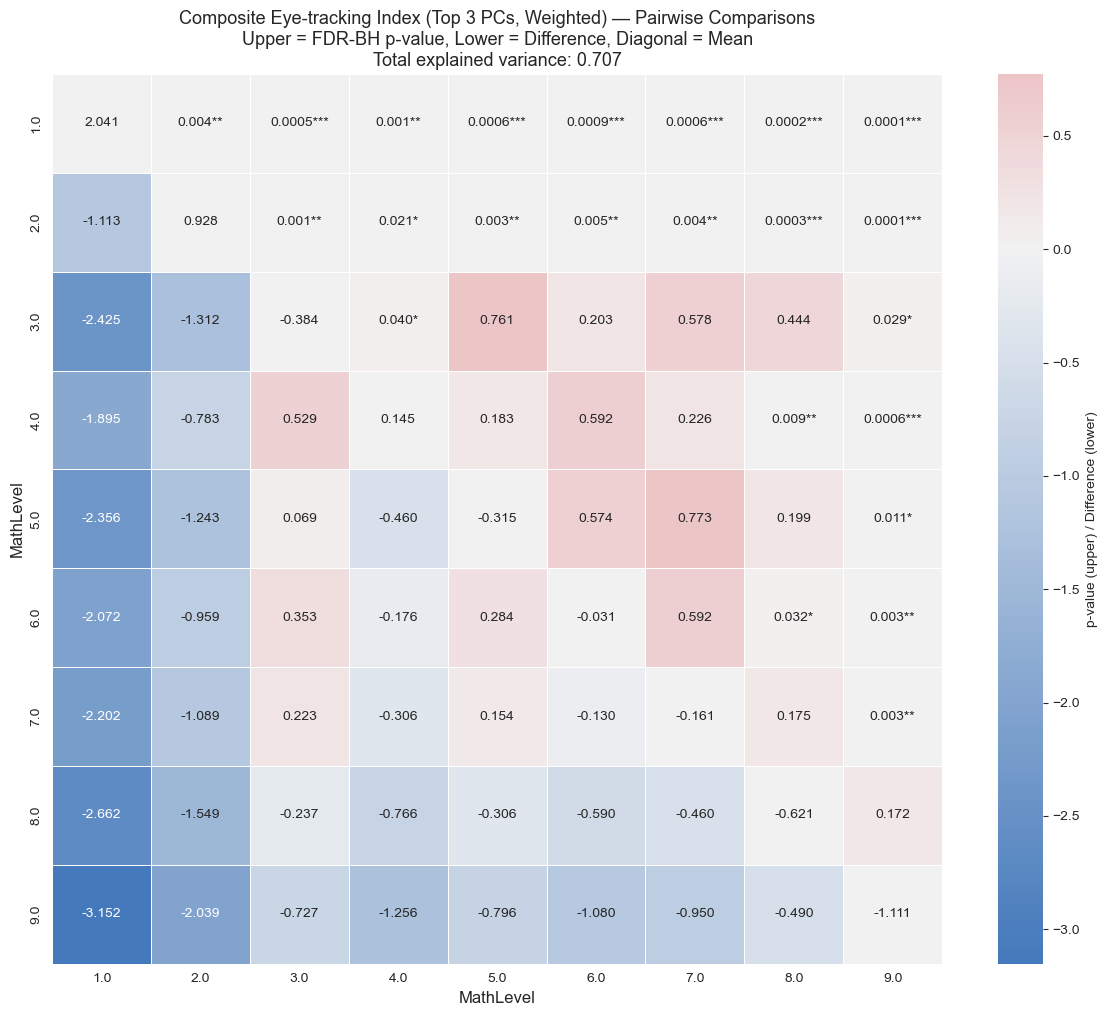

In [539]:
feature_selected = ['Number_of_whole_fixations',
        'Number_of_saccades',
     'Average_peak_velocity_of_saccades', 'Average_amplitude_of_saccades','Mental Demand',  'Performance',
      'Effort', 'Frustration','Count','Correct_Number','Correct_Percentage']
results_diagnol = analyze_composite_index_pairwise(df_combined,feature_selected)
print_composite_analysis_results(results_diagnol)

{'model': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x176007dd2a0>,
 'pairwise':     i  j         p_val      diff         p_adj  abs_diff
 0   1  2  1.098718e-08  1.229618  2.472115e-08  1.229618
 1   1  3  6.000666e-29  2.586760  1.080120e-27  2.586760
 2   1  4  3.893216e-28  2.064889  4.671859e-27  2.064889
 3   1  5  7.932221e-31  2.565672  2.855600e-29  2.565672
 4   1  6  7.087711e-23  2.188664  4.252627e-22  2.188664
 5   1  7  1.029410e-19  2.318654  4.632347e-19  2.318654
 6   1  8  3.513851e-27  2.778653  3.162466e-26  2.778653
 7   1  9  3.345837e-21  3.366809  1.720716e-20  3.366809
 8   2  3  2.618635e-18  1.357142  9.427085e-18  1.357142
 9   2  4  3.461183e-06  0.835272  6.230130e-06  0.835272
 10  2  5  5.088968e-12  1.336054  1.665480e-11  1.336054
 11  2  6  2.303486e-10  0.959046  6.910459e-10  0.959046
 12  2  7  1.654747e-08  1.089036  3.504171e-08  1.089036
 13  2  8  5.527701e-27  1.549035  3.979945e-26  1.549035
 14  2  9  1.147418e-18 

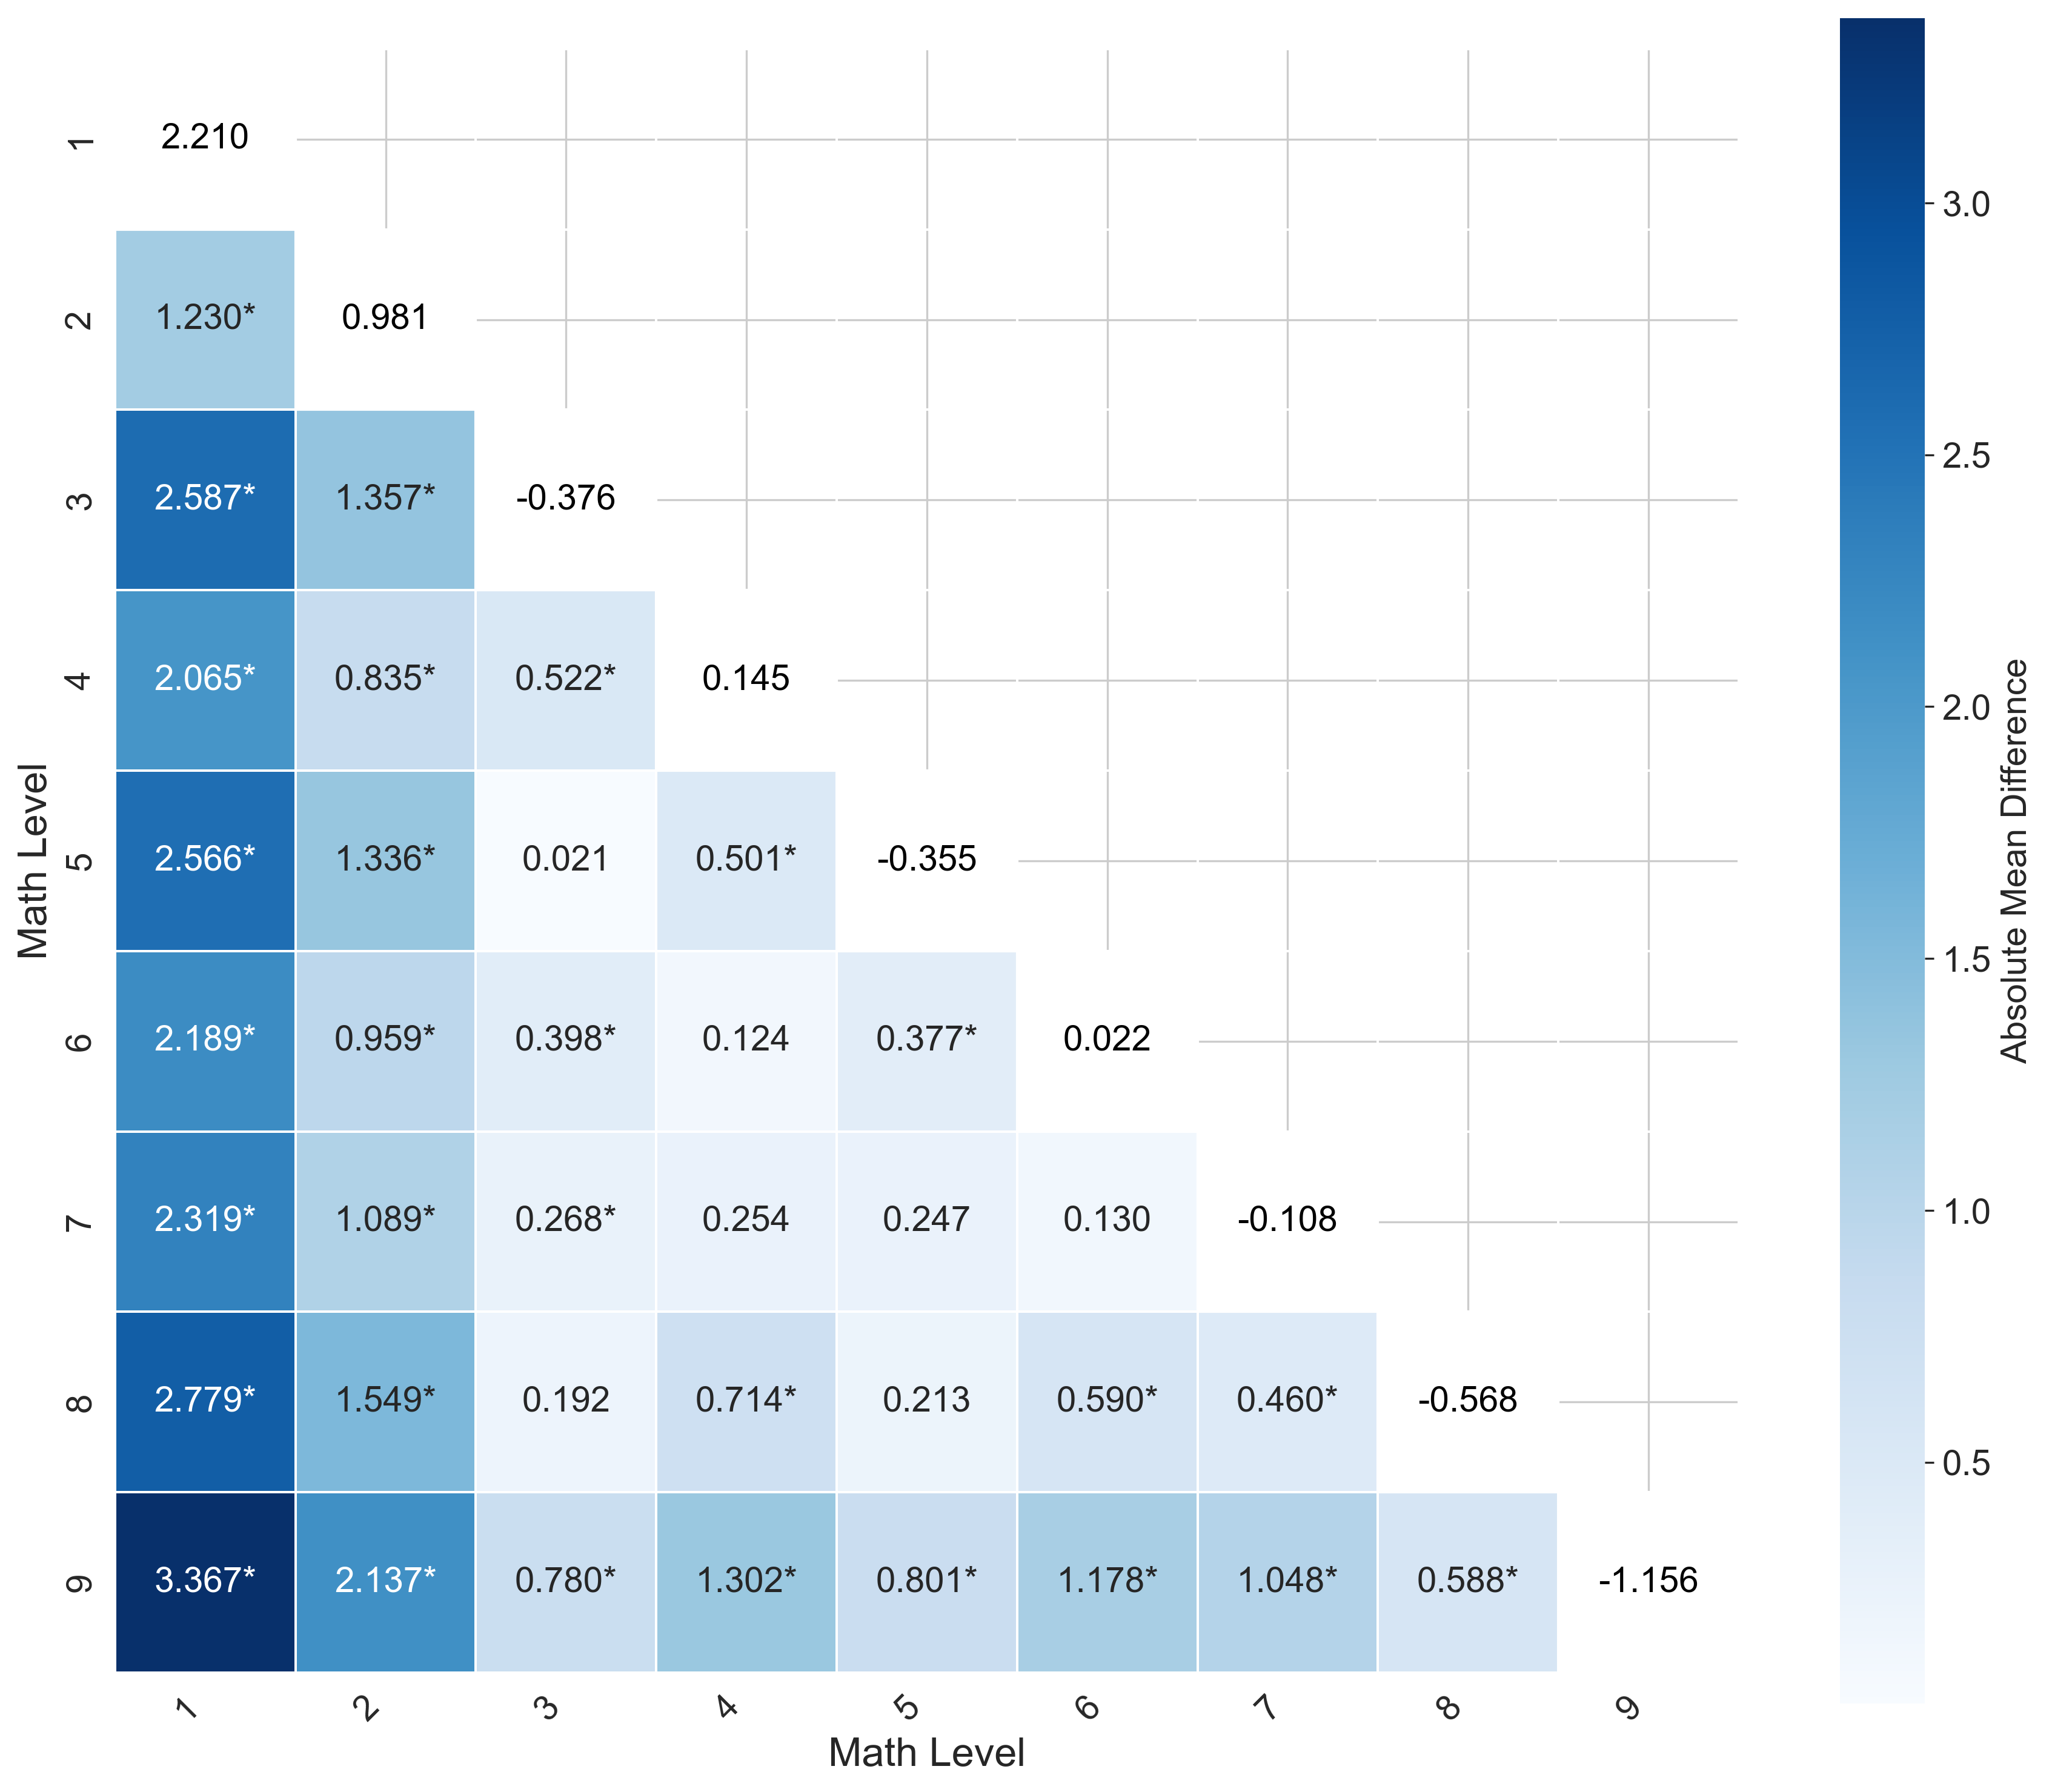

In [540]:
results_mix = analyze_composite_index_mixed(df_combined,feature_selected,subject_col = "Participant")
results_mix

## 5. Linear Regression Using Math Test Variables

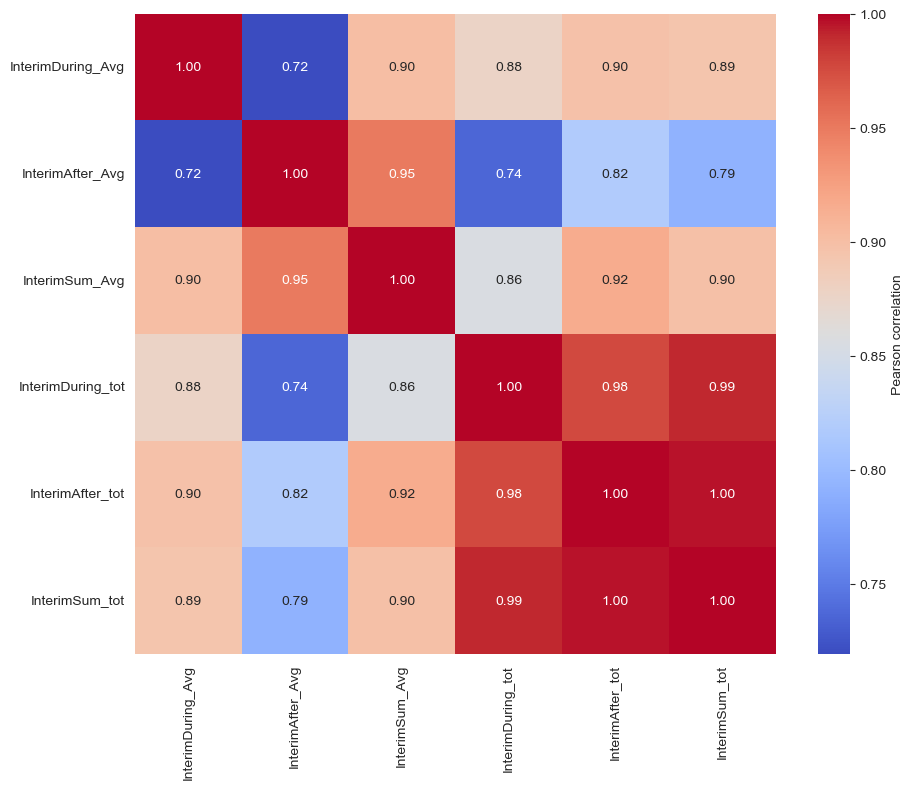

In [541]:
level_means = results_diagnol['level_means']
level_means_1 = results_mix['model_means']
df_model = df_combined.copy()
df_model_1 = df_combined.copy()
df_model['MathLevel'] = df_model['MathLevel'].replace(level_means)
df_model_1['MathLevel'] = df_model_1['MathLevel'].replace(level_means_1)
features_math_linear = [ 'InterimDuring_Avg',
       'InterimAfter_Avg','InterimSum_Avg', 'InterimDuring_tot',
       'InterimAfter_tot', 'InterimSum_tot']
data = df_model[features_math_linear]
corr_matrix = data.corr(method = 'pearson')
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
                square=True, cbar_kws={'label': 'Pearson correlation'})
#plt.title(f'Feature Correlation Matrix (pearson method)', fontsize=14)
plt.tight_layout()
fig = plt.gcf()

In [542]:
results_linear = linear_regression_analysis(df_model,features_math_linear,'MathLevel')
print(results_linear)


=== Linear Regression Results ===

Training Set:
  R² Score: 0.9838
  MAE:      0.0934

Test Set:
  R² Score: 0.9793
  MAE:      0.1011

Feature Coefficients:
          Feature  Coefficient
InterimDuring_tot    -1.102062
 InterimAfter_tot     0.905381
InterimDuring_Avg    -0.469780
   InterimSum_Avg    -0.261787
   InterimSum_tot     0.153336
 InterimAfter_Avg    -0.079878

Intercept: 0.0696
{'model': LinearRegression(), 'scaler': StandardScaler(), 'train_r2': 0.9837789070382151, 'train_mae': 0.09339776260788374, 'test_r2': 0.9792960844742024, 'test_mae': 0.10105720310428648, 'coefficients':              Feature  Coefficient
3  InterimDuring_tot    -1.102062
4   InterimAfter_tot     0.905381
0  InterimDuring_Avg    -0.469780
2     InterimSum_Avg    -0.261787
5     InterimSum_tot     0.153336
1   InterimAfter_Avg    -0.079878, 'intercept': 0.06964081153958303}


In [543]:
results_linear_1 = linear_regression_analysis(df_model_1,features_math_linear,'MathLevel')
print(results_linear_1)


=== Linear Regression Results ===

Training Set:
  R² Score: 0.9761
  MAE:      0.1089

Test Set:
  R² Score: 0.9820
  MAE:      0.1001

Feature Coefficients:
          Feature  Coefficient
InterimDuring_tot    -1.150887
 InterimAfter_tot     0.976623
InterimDuring_Avg    -0.545714
   InterimSum_Avg    -0.281744
   InterimSum_tot     0.174501
 InterimAfter_Avg    -0.058758

Intercept: -0.0138
{'model': LinearRegression(), 'scaler': StandardScaler(), 'train_r2': 0.9760977047139824, 'train_mae': 0.1089137178575295, 'test_r2': 0.9819601359578156, 'test_mae': 0.10012396767393238, 'coefficients':              Feature  Coefficient
3  InterimDuring_tot    -1.150887
4   InterimAfter_tot     0.976623
0  InterimDuring_Avg    -0.545714
2     InterimSum_Avg    -0.281744
5     InterimSum_tot     0.174501
1   InterimAfter_Avg    -0.058758, 'intercept': -0.013806329765852695}


In [544]:
results_ridge = ridge_regression_analysis(df_model,features_math_linear,'MathLevel')
print(results_ridge)


=== Ridge Regression Results ===
Alpha (Regularization strength): 1.0

Training Set:
  R² Score: 0.9749
  MAE:      0.1184

Test Set:
  R² Score: 0.9818
  MAE:      0.1125

Feature Coefficients:
          Feature  Coefficient
InterimDuring_tot    -0.737342
 InterimAfter_tot     0.529539
InterimDuring_Avg    -0.419781
   InterimSum_Avg    -0.202577
   InterimSum_tot     0.050012
 InterimAfter_Avg    -0.022981

Intercept: -0.0130
{'model': Ridge(), 'scaler': StandardScaler(), 'train_r2': 0.9748537547359757, 'train_mae': 0.11842470451578595, 'test_r2': 0.9818322385913237, 'test_mae': 0.11248854514587092, 'coefficients':              Feature  Coefficient
3  InterimDuring_tot    -0.737342
4   InterimAfter_tot     0.529539
0  InterimDuring_Avg    -0.419781
2     InterimSum_Avg    -0.202577
5     InterimSum_tot     0.050012
1   InterimAfter_Avg    -0.022981, 'intercept': -0.012970983227458599}


In [545]:
results_ridge_1 = ridge_regression_analysis(df_model_1,features_math_linear,'MathLevel')
print(results_ridge_1)
print(df_model_1['MathLevel'].unique())


=== Ridge Regression Results ===
Alpha (Regularization strength): 1.0

Training Set:
  R² Score: 0.9693
  MAE:      0.1376

Test Set:
  R² Score: 0.9772
  MAE:      0.1324

Feature Coefficients:
          Feature  Coefficient
InterimDuring_tot    -0.795301
 InterimAfter_tot     0.589831
InterimDuring_Avg    -0.476938
   InterimSum_Avg    -0.216076
   InterimSum_tot     0.065608
 InterimAfter_Avg    -0.003811

Intercept: 0.0145
{'model': Ridge(), 'scaler': StandardScaler(), 'train_r2': 0.9692518865517435, 'train_mae': 0.13763424414951037, 'test_r2': 0.977160616998845, 'test_mae': 0.13244858150139002, 'coefficients':              Feature  Coefficient
3  InterimDuring_tot    -0.795301
4   InterimAfter_tot     0.589831
0  InterimDuring_Avg    -0.476938
2     InterimSum_Avg    -0.216076
5     InterimSum_tot     0.065608
1   InterimAfter_Avg    -0.003811, 'intercept': 0.014488124061924079}
[ 2.21036573  0.98074788 -0.37639382  0.14547632 -0.35530591  0.02170165
 -0.10828858 -0.56828757 -1.1

In [546]:
results_elastic = elastic_net_regression_analysis(df_model,features_math_linear,'MathLevel')
print(results_elastic)


=== Elastic Net Regression Results ===
Alpha: 1.0000
L1 Ratio: 0.50

Training Set:
  R² Score: 0.4731
  MAE:      0.4303

Test Set:
  R² Score: 0.4762
  MAE:      0.4483

Feature Coefficients:
          Feature  Coefficient
InterimDuring_Avg    -0.098928
InterimDuring_tot    -0.062062
   InterimSum_tot    -0.040018
   InterimSum_Avg    -0.023984
 InterimAfter_tot    -0.017273
 InterimAfter_Avg    -0.000000

Intercept: 0.0032
{'model': ElasticNet(), 'scaler': StandardScaler(), 'train_r2': 0.47309114702704536, 'train_mae': 0.43029152597166587, 'test_r2': 0.47616275016056175, 'test_mae': 0.4482954476593985, 'coefficients':              Feature  Coefficient
0  InterimDuring_Avg    -0.098928
3  InterimDuring_tot    -0.062062
5     InterimSum_tot    -0.040018
2     InterimSum_Avg    -0.023984
4   InterimAfter_tot    -0.017273
1   InterimAfter_Avg    -0.000000, 'intercept': 0.0032344120705077484, 'best_alpha': 1.0, 'best_l1_ratio': 0.5}
